Original dataset shape: (4436, 1024)
Original class distribution: [3611  825]
After SMOTE shape: (7222, 1024)
Balanced class distribution: [3611 3611]
Average KL divergence (SMOTE || Original): 0.00810122962375583


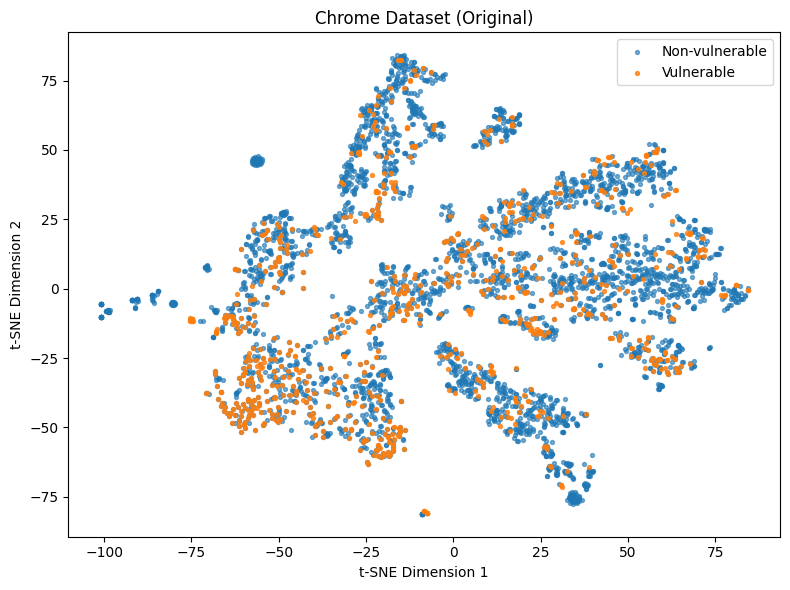

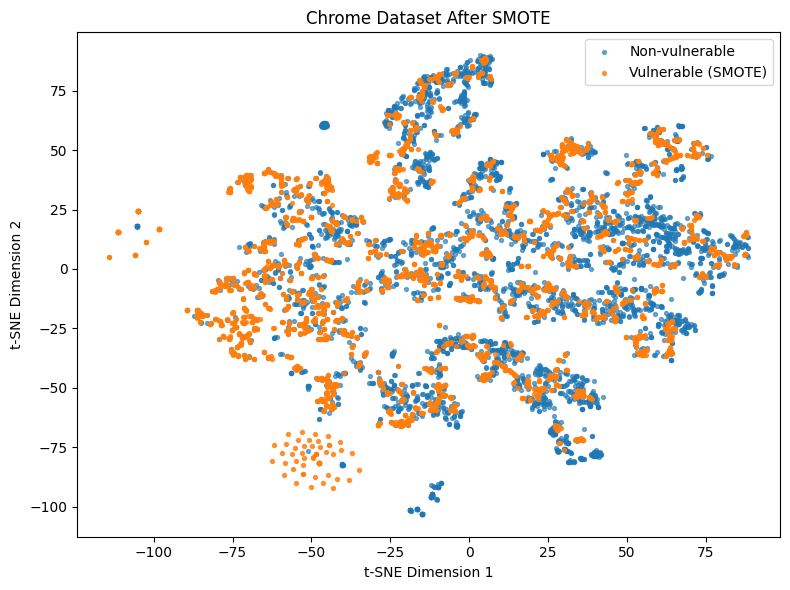

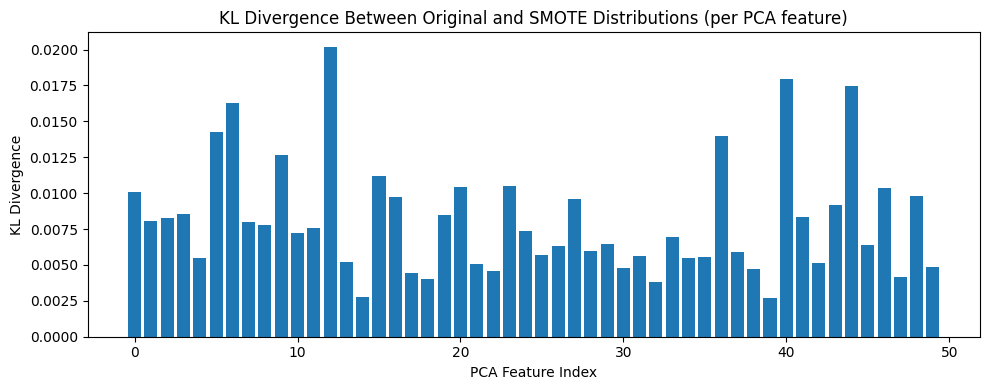

In [1]:
"""
Cross-Project Vulnerability Detection
---------------------------------------------------
Domain shift observation in Chrome dataset (No SMOTE vs SMOTE)
"""


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Load Chrome dataset
# -------------------------
X = np.load("dataset/chrome_embeddings.npy")
y = np.load("dataset/chrome_labels.npy")

print("Original dataset shape:", X.shape)
print("Original class distribution:", np.bincount(y))

# -------------------------
# Apply SMOTE
# -------------------------
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("After SMOTE shape:", X_smote.shape)
print("Balanced class distribution:", np.bincount(y_smote))

# -------------------------
# PCA for dimensionality reduction
# -------------------------
pca = PCA(n_components=50, random_state=42)
pca.fit(X)  # fit on original for consistent space

X_pca_original = pca.transform(X)
X_pca_smote = pca.transform(X_smote)

# -------------------------
# Compute KL divergence per PCA feature
# -------------------------
kl_values = []
bins = 50  # histogram bins

for i in range(X_pca_original.shape[1]):
    hist_orig, _ = np.histogram(X_pca_original[:, i], bins=bins, density=True)
    hist_smote, _ = np.histogram(X_pca_smote[:, i], bins=bins, density=True)
    
    # avoid log(0)
    hist_orig += 1e-10
    hist_smote += 1e-10
    
    kl = entropy(hist_smote, hist_orig)  # KL(SMOTE || Original)
    kl_values.append(kl)

avg_kl = np.mean(kl_values)
print("Average KL divergence (SMOTE || Original):", avg_kl)

# -------------------------
# PCA → t-SNE for visualization
# -------------------------
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            max_iter=1000, random_state=42)

X_tsne_original = tsne.fit_transform(X_pca_original)
X_tsne_smote = tsne.fit_transform(X_pca_smote)

# -------------------------
# Plot Original Chrome Data
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne_original[y==0,0],
    X_tsne_original[y==0,1],
    s=8,
    alpha=0.6,
    label="Non-vulnerable"
)

plt.scatter(
    X_tsne_original[y==1,0],
    X_tsne_original[y==1,1],
    s=8,
    alpha=0.8,
    label="Vulnerable"
)

plt.title("Chrome Dataset (Original)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot Chrome Data After SMOTE
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne_smote[y_smote==0,0],
    X_tsne_smote[y_smote==0,1],
    s=8,
    alpha=0.6,
    label="Non-vulnerable"
)

plt.scatter(
    X_tsne_smote[y_smote==1,0],
    X_tsne_smote[y_smote==1,1],
    s=8,
    alpha=0.8,
    label="Vulnerable (SMOTE)"
)

plt.title("Chrome Dataset After SMOTE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot KL divergence per PCA feature
# -------------------------
plt.figure(figsize=(10,4))
plt.bar(range(len(kl_values)), kl_values)
plt.xlabel("PCA Feature Index")
plt.ylabel("KL Divergence")
plt.title("KL Divergence Between Original and SMOTE Distributions (per PCA feature)")
plt.tight_layout()
plt.show()

Original dataset shape: (18298, 1024)
Original class distribution: [16883  1415]
After SMOTE shape: (33766, 1024)
Balanced class distribution: [16883 16883]
Average KL divergence (SMOTE || Original): 0.016252076906068287


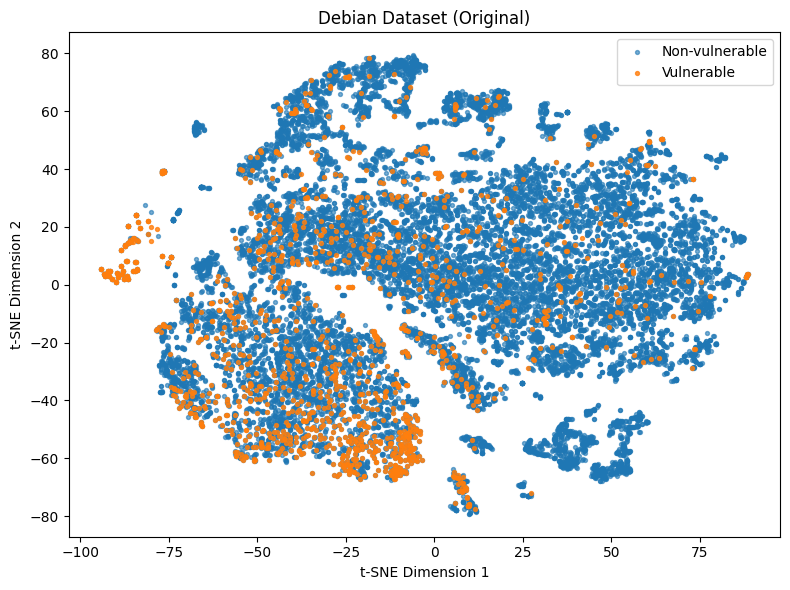

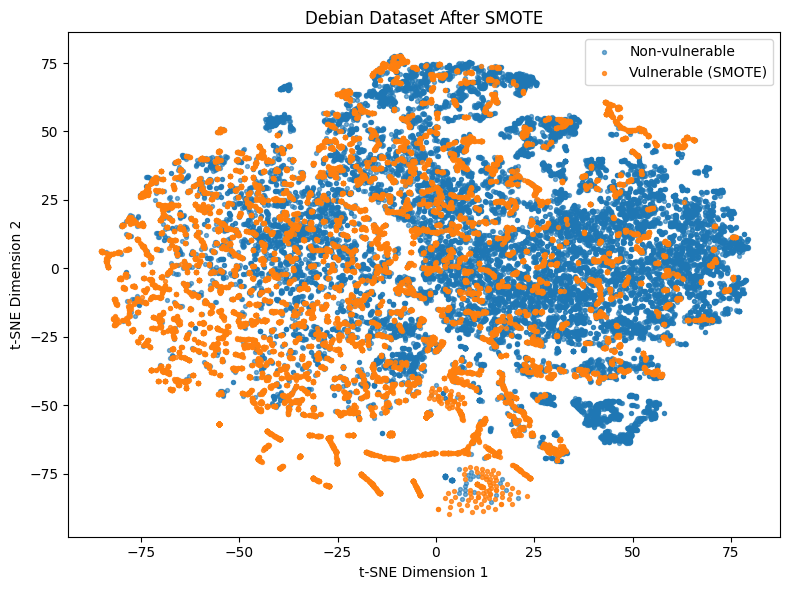

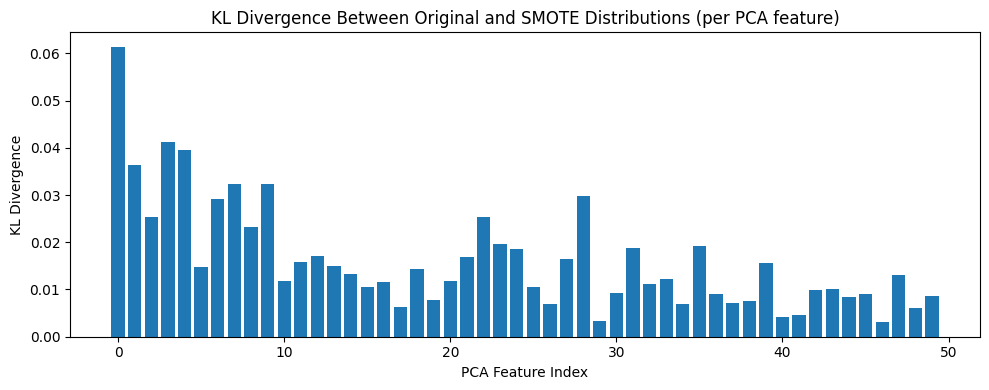

In [2]:
"""
Cross-Project Vulnerability Detection
---------------------------------------------------
Domain shift observation in Debian dataset (No SMOTE vs SMOTE)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Load Debian dataset
# -------------------------
X = np.load("dataset/debian_embeddings.npy")
y = np.load("dataset/debian_labels.npy")

print("Original dataset shape:", X.shape)
print("Original class distribution:", np.bincount(y))

# -------------------------
# Apply SMOTE
# -------------------------
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("After SMOTE shape:", X_smote.shape)
print("Balanced class distribution:", np.bincount(y_smote))

# -------------------------
# PCA for dimensionality reduction
# -------------------------
pca = PCA(n_components=50, random_state=42)
pca.fit(X)  # fit on original for consistent space

X_pca_original = pca.transform(X)
X_pca_smote = pca.transform(X_smote)

# -------------------------
# Compute KL divergence per PCA feature
# -------------------------
kl_values = []
bins = 50  # histogram bins

for i in range(X_pca_original.shape[1]):
    hist_orig, _ = np.histogram(X_pca_original[:, i], bins=bins, density=True)
    hist_smote, _ = np.histogram(X_pca_smote[:, i], bins=bins, density=True)
    
    # avoid log(0)
    hist_orig += 1e-10
    hist_smote += 1e-10
    
    kl = entropy(hist_smote, hist_orig)  # KL(SMOTE || Original)
    kl_values.append(kl)

avg_kl = np.mean(kl_values)
print("Average KL divergence (SMOTE || Original):", avg_kl)

# -------------------------
# PCA → t-SNE for visualization
# -------------------------
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            max_iter=1000, random_state=42)

X_tsne_original = tsne.fit_transform(X_pca_original)
X_tsne_smote = tsne.fit_transform(X_pca_smote)

# -------------------------
# Plot Original Debian Data
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne_original[y==0,0],
    X_tsne_original[y==0,1],
    s=8,
    alpha=0.6,
    label="Non-vulnerable"
)

plt.scatter(
    X_tsne_original[y==1,0],
    X_tsne_original[y==1,1],
    s=8,
    alpha=0.8,
    label="Vulnerable"
)

plt.title("Debian Dataset (Original)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot Debian Data After SMOTE
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne_smote[y_smote==0,0],
    X_tsne_smote[y_smote==0,1],
    s=8,
    alpha=0.6,
    label="Non-vulnerable"
)

plt.scatter(
    X_tsne_smote[y_smote==1,0],
    X_tsne_smote[y_smote==1,1],
    s=8,
    alpha=0.8,
    label="Vulnerable (SMOTE)"
)

plt.title("Debian Dataset After SMOTE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot KL divergence per PCA feature
# -------------------------
plt.figure(figsize=(10,4))
plt.bar(range(len(kl_values)), kl_values)
plt.xlabel("PCA Feature Index")
plt.ylabel("KL Divergence")
plt.title("KL Divergence Between Original and SMOTE Distributions (per PCA feature)")
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# MMD² function
# -------------------------
def compute_mmd(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    
    return XX.mean() + YY.mean() - 2 * XY.mean()

# -------------------------
# Load datasets
# -------------------------
chrome_X = np.load("dataset/chrome_embeddings.npy")
chrome_y = np.load("dataset/chrome_labels.npy")

debian_X = np.load("dataset/debian_embeddings.npy")
debian_y = np.load("dataset/debian_labels.npy")

# -------------------------
# Apply SMOTE on Debian
# -------------------------
smote = SMOTE(random_state=42)
debian_X_smote, debian_y_smote = smote.fit_resample(debian_X, debian_y)

print("Original Debian shape:", debian_X.shape)
print("SMOTE Debian shape:", debian_X_smote.shape)

# -------------------------
# PCA (fit on ORIGINAL Debian or combined)
# -------------------------
pca = PCA(n_components=50, random_state=42)

# Better option: fit on BOTH datasets for fair comparison
pca.fit(np.vstack([chrome_X, debian_X]))

chrome_pca = pca.transform(chrome_X)
debian_pca = pca.transform(debian_X)
debian_smote_pca = pca.transform(debian_X_smote)

# -------------------------
# Compute MMD²
# -------------------------

mmd_original = compute_mmd(debian_pca, chrome_pca)
mmd_smote = compute_mmd(debian_smote_pca, chrome_pca)

print("MMD² (Debian vs Chrome):", mmd_original)
print("MMD² (SMOTE Debian vs Chrome):", mmd_smote)

Original Debian shape: (18298, 1024)
SMOTE Debian shape: (33766, 1024)
MMD² (Debian vs Chrome): 0.008792315
MMD² (SMOTE Debian vs Chrome): 0.017415434


Original dataset shape: (4436, 1024)
Original class distribution: [3611  825]
After ADASYN shape: (7085, 1024)
Balanced class distribution: [3611 3474]
Average KL divergence (ADASYN || Original): 0.007728170109371341


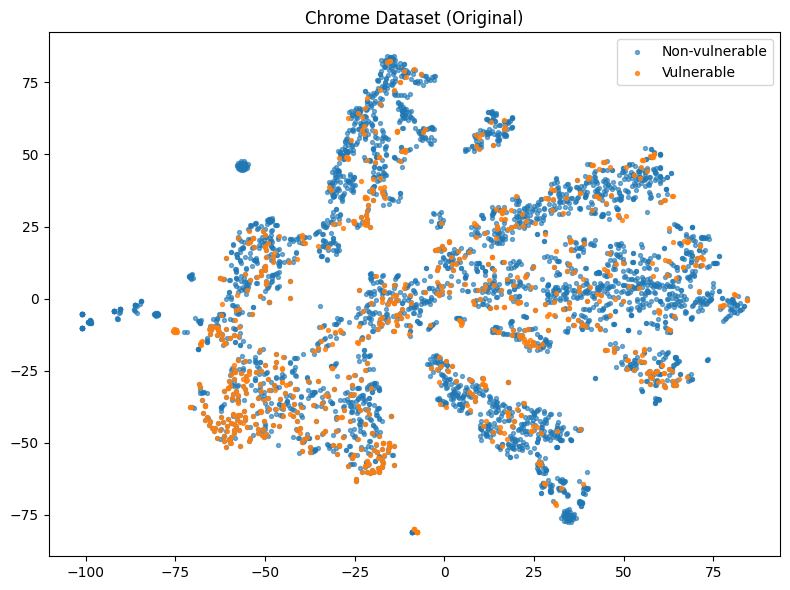

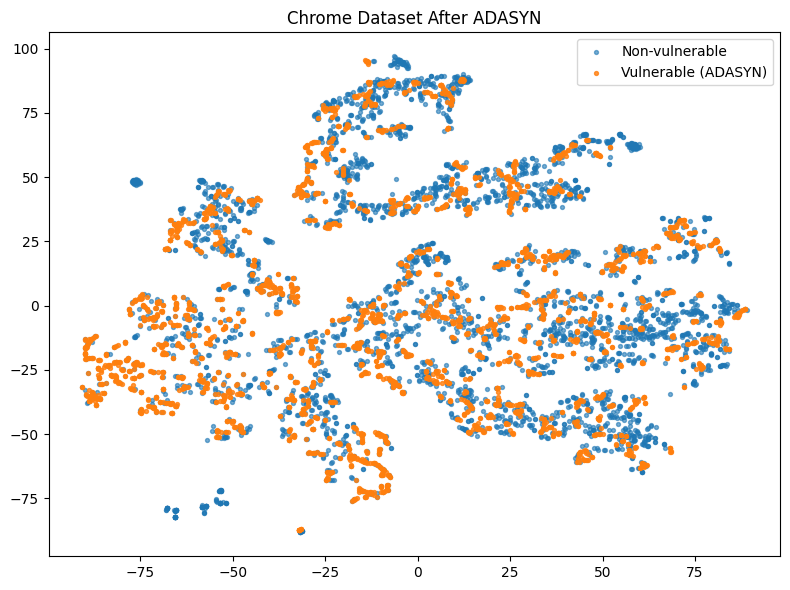

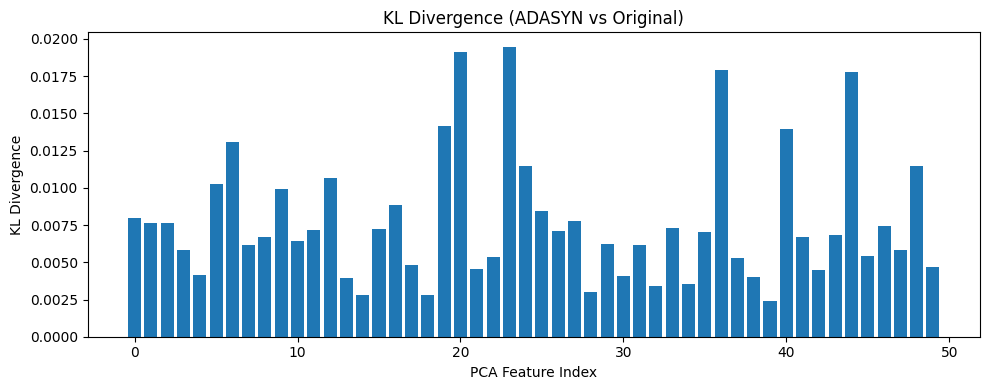

In [4]:
"""
Cross-Project Vulnerability Detection
---------------------------------------------------
Domain shift observation in Chrome dataset (No Balancing vs ADASYN)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import ADASYN
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Load Chrome dataset
# -------------------------
X = np.load("dataset/chrome_embeddings.npy")
y = np.load("dataset/chrome_labels.npy")

print("Original dataset shape:", X.shape)
print("Original class distribution:", np.bincount(y))

# -------------------------
# Apply ADASYN
# -------------------------
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

print("After ADASYN shape:", X_adasyn.shape)
print("Balanced class distribution:", np.bincount(y_adasyn))

# -------------------------
# PCA (fit ONLY on original)
# -------------------------
pca = PCA(n_components=50, random_state=42)
pca.fit(X)

X_pca_original = pca.transform(X)
X_pca_adasyn = pca.transform(X_adasyn)

# -------------------------
# KL divergence per feature
# -------------------------
kl_values = []
bins = 50

for i in range(X_pca_original.shape[1]):
    hist_orig, _ = np.histogram(X_pca_original[:, i], bins=bins, density=True)
    hist_adasyn, _ = np.histogram(X_pca_adasyn[:, i], bins=bins, density=True)

    hist_orig += 1e-10
    hist_adasyn += 1e-10

    kl = entropy(hist_adasyn, hist_orig)  # KL(ADASYN || Original)
    kl_values.append(kl)

avg_kl = np.mean(kl_values)
print("Average KL divergence (ADASYN || Original):", avg_kl)

# -------------------------
# t-SNE
# -------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne_original = tsne.fit_transform(X_pca_original)
X_tsne_adasyn = tsne.fit_transform(X_pca_adasyn)

# -------------------------
# Plot Original
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_tsne_original[y==0,0], X_tsne_original[y==0,1],
            s=8, alpha=0.6, label="Non-vulnerable")

plt.scatter(X_tsne_original[y==1,0], X_tsne_original[y==1,1],
            s=8, alpha=0.8, label="Vulnerable")

plt.title("Chrome Dataset (Original)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot ADASYN
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_tsne_adasyn[y_adasyn==0,0], X_tsne_adasyn[y_adasyn==0,1],
            s=8, alpha=0.6, label="Non-vulnerable")

plt.scatter(X_tsne_adasyn[y_adasyn==1,0], X_tsne_adasyn[y_adasyn==1,1],
            s=8, alpha=0.8, label="Vulnerable (ADASYN)")

plt.title("Chrome Dataset After ADASYN")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# KL Bar Plot
# -------------------------
plt.figure(figsize=(10,4))
plt.bar(range(len(kl_values)), kl_values)
plt.xlabel("PCA Feature Index")
plt.ylabel("KL Divergence")
plt.title("KL Divergence (ADASYN vs Original)")
plt.tight_layout()
plt.show()

Original dataset shape: (18298, 1024)
Original class distribution: [16883  1415]
After ADASYN shape: (33799, 1024)
Balanced class distribution: [16883 16916]
Average KL divergence (ADASYN || Original): 0.013329770770057304


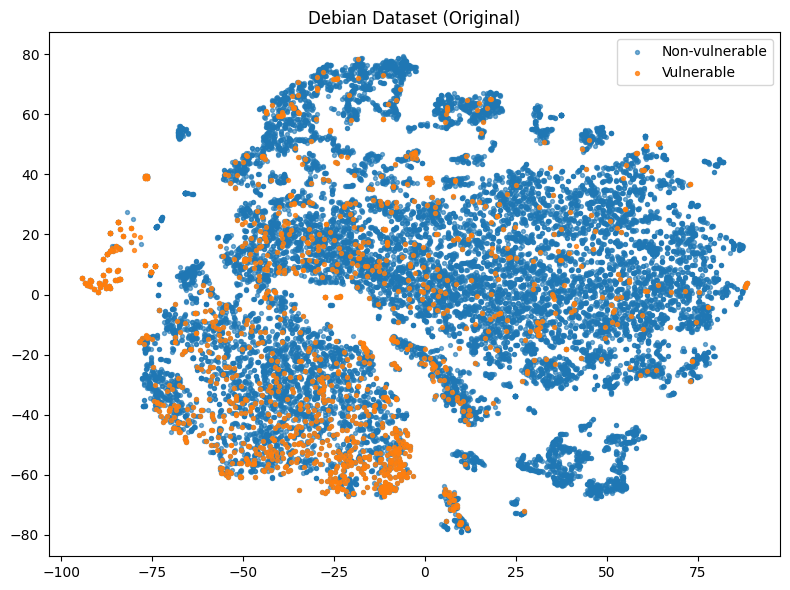

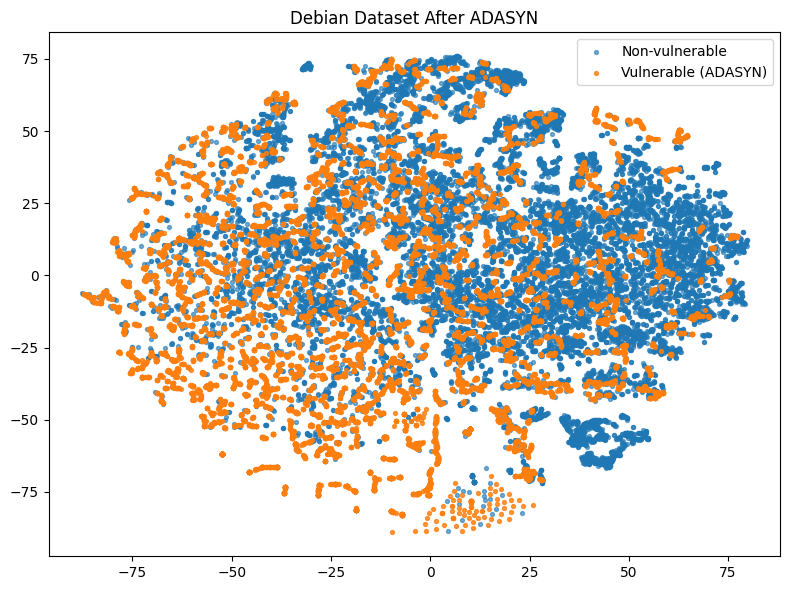

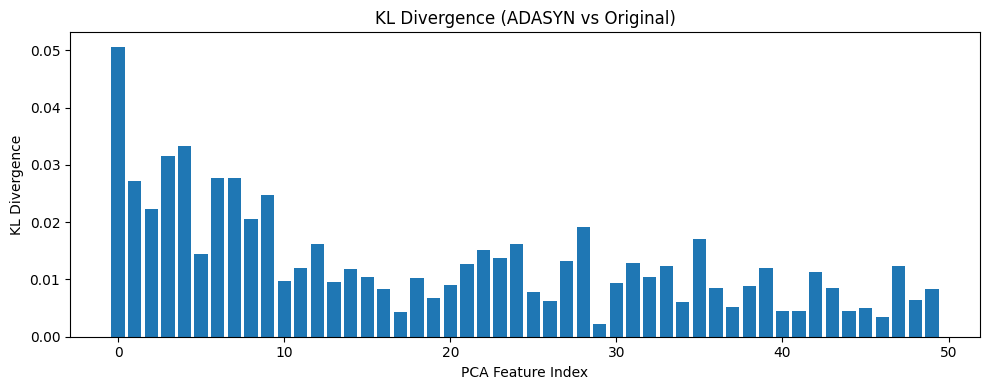

In [5]:
"""
Cross-Project Vulnerability Detection
---------------------------------------------------
Domain shift observation in Debian dataset (No Balancing vs ADASYN)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import ADASYN
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Load Debian dataset
# -------------------------
X = np.load("dataset/debian_embeddings.npy")
y = np.load("dataset/debian_labels.npy")

print("Original dataset shape:", X.shape)
print("Original class distribution:", np.bincount(y))

# -------------------------
# Apply ADASYN
# -------------------------
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

print("After ADASYN shape:", X_adasyn.shape)
print("Balanced class distribution:", np.bincount(y_adasyn))

# -------------------------
# PCA (fit ONLY on original)
# -------------------------
pca = PCA(n_components=50, random_state=42)
pca.fit(X)

X_pca_original = pca.transform(X)
X_pca_adasyn = pca.transform(X_adasyn)

# -------------------------
# KL divergence per feature
# -------------------------
kl_values = []
bins = 50

for i in range(X_pca_original.shape[1]):
    hist_orig, _ = np.histogram(X_pca_original[:, i], bins=bins, density=True)
    hist_adasyn, _ = np.histogram(X_pca_adasyn[:, i], bins=bins, density=True)

    hist_orig += 1e-10
    hist_adasyn += 1e-10

    kl = entropy(hist_adasyn, hist_orig)  # KL(ADASYN || Original)
    kl_values.append(kl)

avg_kl = np.mean(kl_values)
print("Average KL divergence (ADASYN || Original):", avg_kl)

# -------------------------
# t-SNE
# -------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne_original = tsne.fit_transform(X_pca_original)
X_tsne_adasyn = tsne.fit_transform(X_pca_adasyn)

# -------------------------
# Plot Original
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_tsne_original[y==0,0], X_tsne_original[y==0,1],
            s=8, alpha=0.6, label="Non-vulnerable")

plt.scatter(X_tsne_original[y==1,0], X_tsne_original[y==1,1],
            s=8, alpha=0.8, label="Vulnerable")

plt.title("Debian Dataset (Original)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot ADASYN
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_tsne_adasyn[y_adasyn==0,0], X_tsne_adasyn[y_adasyn==0,1],
            s=8, alpha=0.6, label="Non-vulnerable")

plt.scatter(X_tsne_adasyn[y_adasyn==1,0], X_tsne_adasyn[y_adasyn==1,1],
            s=8, alpha=0.8, label="Vulnerable (ADASYN)")

plt.title("Debian Dataset After ADASYN")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# KL Bar Plot
# -------------------------
plt.figure(figsize=(10,4))
plt.bar(range(len(kl_values)), kl_values)
plt.xlabel("PCA Feature Index")
plt.ylabel("KL Divergence")
plt.title("KL Divergence (ADASYN vs Original)")
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from imblearn.over_sampling import ADASYN
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# MMD² function
# -------------------------
def compute_mmd(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    
    return XX.mean() + YY.mean() - 2 * XY.mean()

# -------------------------
# Load datasets
# -------------------------
chrome_X = np.load("dataset/chrome_embeddings.npy")
chrome_y = np.load("dataset/chrome_labels.npy")

debian_X = np.load("dataset/debian_embeddings.npy")
debian_y = np.load("dataset/debian_labels.npy")

# -------------------------
# Apply ADASYN on Debian
# -------------------------
adasyn = ADASYN(random_state=42)
debian_X_adasyn, debian_y_adasyn = adasyn.fit_resample(debian_X, debian_y)

print("Original Debian shape:", debian_X.shape)
print("ADASYN Debian shape:", debian_X_adasyn.shape)

# -------------------------
# PCA (shared space)
# -------------------------
pca = PCA(n_components=50, random_state=42)

# Fit on BOTH datasets for fair comparison
pca.fit(np.vstack([chrome_X, debian_X]))

chrome_pca = pca.transform(chrome_X)
debian_pca = pca.transform(debian_X)
debian_adasyn_pca = pca.transform(debian_X_adasyn)

# -------------------------
# Compute MMD²
# -------------------------
mmd_original = compute_mmd(debian_pca, chrome_pca)
mmd_adasyn = compute_mmd(debian_adasyn_pca, chrome_pca)

print("MMD² (Debian vs Chrome):", mmd_original)
print("MMD² (ADASYN Debian vs Chrome):", mmd_adasyn)

Original Debian shape: (18298, 1024)
ADASYN Debian shape: (33799, 1024)
MMD² (Debian vs Chrome): 0.008792315
MMD² (ADASYN Debian vs Chrome): 0.016145669


Original dataset shape: (4436, 1024)
Original class distribution: [3611  825]
After SVMSMOTE shape: (7222, 1024)
Balanced class distribution: [3611 3611]
Average KL divergence (SVMSMOTE || Original): 0.027142250794593474


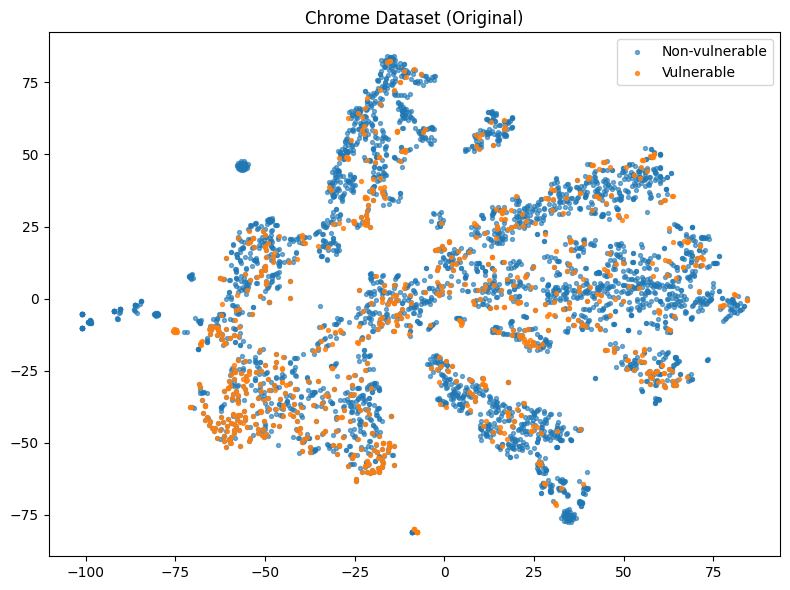

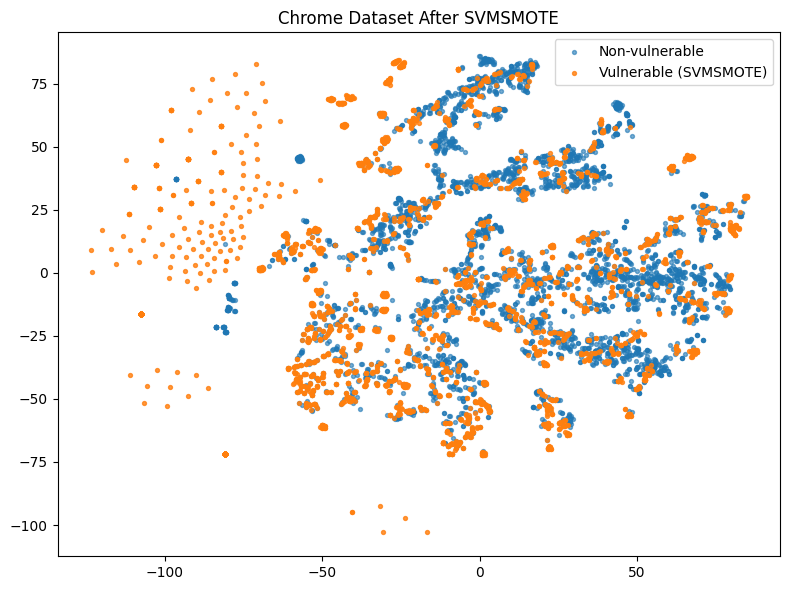

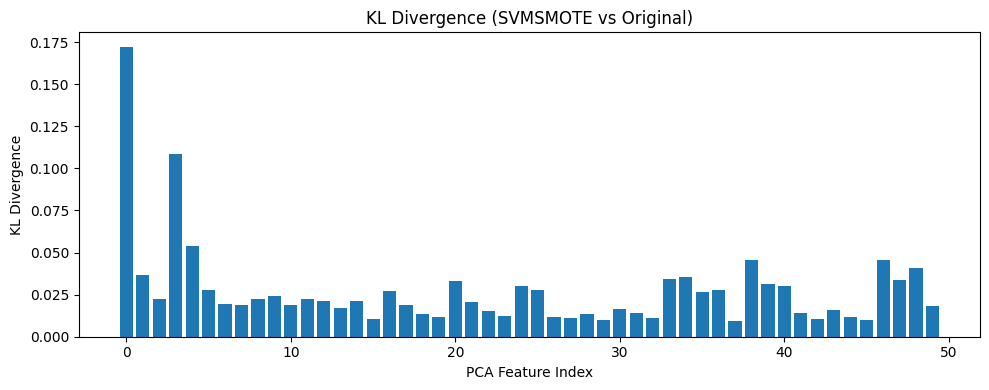

In [8]:
"""
Cross-Project Vulnerability Detection
---------------------------------------------------
Domain shift observation in Chrome dataset (No Balancing vs SVMSMOTE)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import SVMSMOTE
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Load Chrome dataset
# -------------------------
X = np.load("dataset/chrome_embeddings.npy")
y = np.load("dataset/chrome_labels.npy")

print("Original dataset shape:", X.shape)
print("Original class distribution:", np.bincount(y))

# -------------------------
# Apply SVMSMOTE
# -------------------------
svm_smote = SVMSMOTE(random_state=42)
X_svm, y_svm = svm_smote.fit_resample(X, y)

print("After SVMSMOTE shape:", X_svm.shape)
print("Balanced class distribution:", np.bincount(y_svm))

# -------------------------
# PCA (fit on original)
# -------------------------
pca = PCA(n_components=50, random_state=42)
pca.fit(X)

X_pca_original = pca.transform(X)
X_pca_svm = pca.transform(X_svm)

# -------------------------
# KL divergence
# -------------------------
kl_values = []
bins = 50

for i in range(X_pca_original.shape[1]):
    hist_orig, _ = np.histogram(X_pca_original[:, i], bins=bins, density=True)
    hist_svm, _ = np.histogram(X_pca_svm[:, i], bins=bins, density=True)

    hist_orig += 1e-10
    hist_svm += 1e-10

    kl = entropy(hist_svm, hist_orig)  # KL(SVMSMOTE || Original)
    kl_values.append(kl)

avg_kl = np.mean(kl_values)
print("Average KL divergence (SVMSMOTE || Original):", avg_kl)

# -------------------------
# t-SNE
# -------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne_original = tsne.fit_transform(X_pca_original)
X_tsne_svm = tsne.fit_transform(X_pca_svm)

# -------------------------
# Plot Original
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_tsne_original[y==0,0], X_tsne_original[y==0,1],
            s=8, alpha=0.6, label="Non-vulnerable")

plt.scatter(X_tsne_original[y==1,0], X_tsne_original[y==1,1],
            s=8, alpha=0.8, label="Vulnerable")

plt.title("Chrome Dataset (Original)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot SVMSMOTE
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_tsne_svm[y_svm==0,0], X_tsne_svm[y_svm==0,1],
            s=8, alpha=0.6, label="Non-vulnerable")

plt.scatter(X_tsne_svm[y_svm==1,0], X_tsne_svm[y_svm==1,1],
            s=8, alpha=0.8, label="Vulnerable (SVMSMOTE)")

plt.title("Chrome Dataset After SVMSMOTE")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# KL Bar Plot
# -------------------------
plt.figure(figsize=(10,4))
plt.bar(range(len(kl_values)), kl_values)
plt.xlabel("PCA Feature Index")
plt.ylabel("KL Divergence")
plt.title("KL Divergence (SVMSMOTE vs Original)")
plt.tight_layout()
plt.show()

Original dataset shape: (18298, 1024)
Original class distribution: [16883  1415]
After SVMSMOTE shape: (33766, 1024)
Balanced class distribution: [16883 16883]
Average KL divergence (SVMSMOTE || Original): 0.043067037673796535


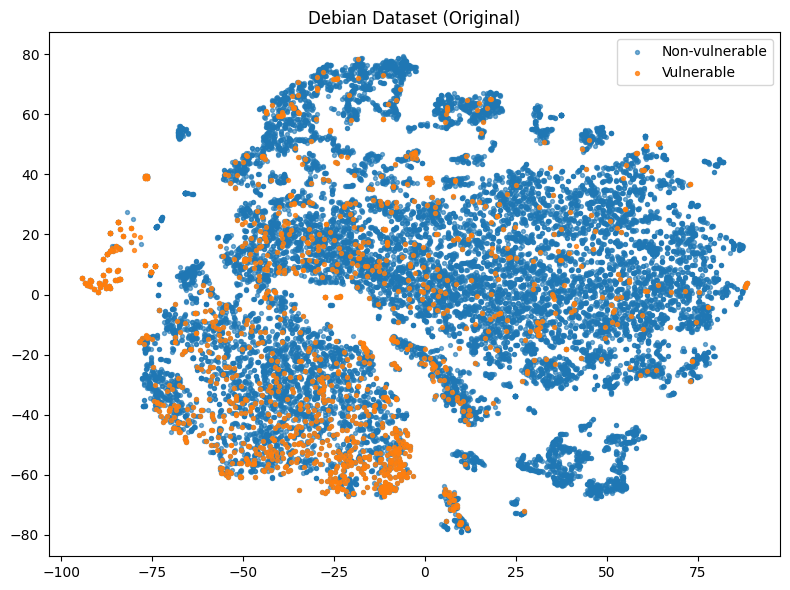

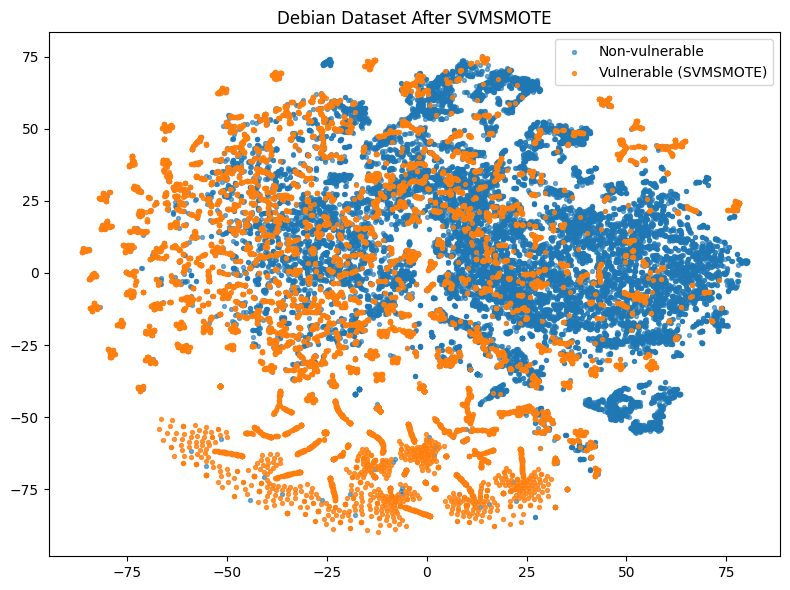

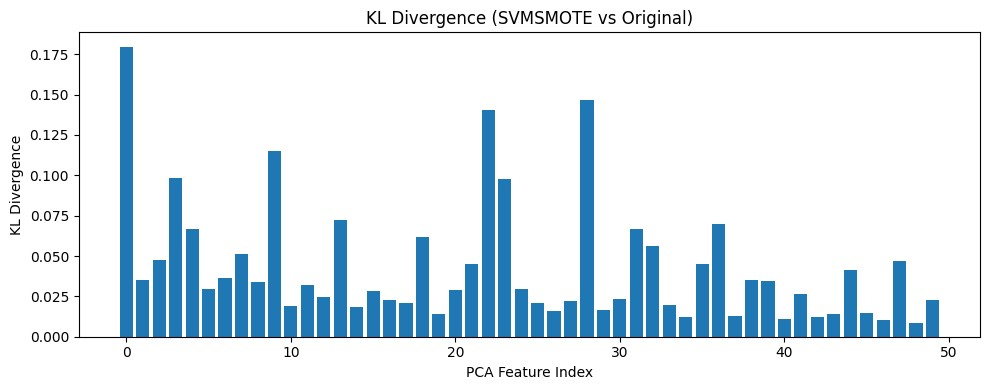

In [14]:
"""
Cross-Project Vulnerability Detection
---------------------------------------------------
Domain shift observation in Debian dataset (No Balancing vs SVMSMOTE)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import SVMSMOTE
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Load Debian dataset
# -------------------------
X = np.load("dataset/debian_embeddings.npy")
y = np.load("dataset/debian_labels.npy")

print("Original dataset shape:", X.shape)
print("Original class distribution:", np.bincount(y))

# -------------------------
# Apply SVMSMOTE
# -------------------------
svm_smote = SVMSMOTE(random_state=42)
X_svm, y_svm = svm_smote.fit_resample(X, y)

print("After SVMSMOTE shape:", X_svm.shape)
print("Balanced class distribution:", np.bincount(y_svm))

# -------------------------
# PCA (fit on original)
# -------------------------
pca = PCA(n_components=50, random_state=42)
pca.fit(X)

X_pca_original = pca.transform(X)
X_pca_svm = pca.transform(X_svm)

# -------------------------
# KL divergence
# -------------------------
kl_values = []
bins = 50

for i in range(X_pca_original.shape[1]):
    hist_orig, _ = np.histogram(X_pca_original[:, i], bins=bins, density=True)
    hist_svm, _ = np.histogram(X_pca_svm[:, i], bins=bins, density=True)

    hist_orig += 1e-10
    hist_svm += 1e-10

    kl = entropy(hist_svm, hist_orig)  # KL(SVMSMOTE || Original)
    kl_values.append(kl)

avg_kl = np.mean(kl_values)
print("Average KL divergence (SVMSMOTE || Original):", avg_kl)

# -------------------------
# t-SNE
# -------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne_original = tsne.fit_transform(X_pca_original)
X_tsne_svm = tsne.fit_transform(X_pca_svm)

# -------------------------
# Plot Original
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_tsne_original[y==0,0], X_tsne_original[y==0,1],
            s=8, alpha=0.6, label="Non-vulnerable")

plt.scatter(X_tsne_original[y==1,0], X_tsne_original[y==1,1],
            s=8, alpha=0.8, label="Vulnerable")

plt.title("Debian Dataset (Original)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot SVMSMOTE
# -------------------------
plt.figure(figsize=(8,6))

plt.scatter(X_tsne_svm[y_svm==0,0], X_tsne_svm[y_svm==0,1],
            s=8, alpha=0.6, label="Non-vulnerable")

plt.scatter(X_tsne_svm[y_svm==1,0], X_tsne_svm[y_svm==1,1],
            s=8, alpha=0.8, label="Vulnerable (SVMSMOTE)")

plt.title("Debian Dataset After SVMSMOTE")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# KL Bar Plot
# -------------------------
plt.figure(figsize=(10,4))
plt.bar(range(len(kl_values)), kl_values)
plt.xlabel("PCA Feature Index")
plt.ylabel("KL Divergence")
plt.title("KL Divergence (SVMSMOTE vs Original)")
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from imblearn.over_sampling import SVMSMOTE
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# MMD² function
# -------------------------
def compute_mmd(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    
    return XX.mean() + YY.mean() - 2 * XY.mean()

# -------------------------
# Load datasets
# -------------------------
chrome_X = np.load("dataset/chrome_embeddings.npy")
chrome_y = np.load("dataset/chrome_labels.npy")

debian_X = np.load("dataset/debian_embeddings.npy")
debian_y = np.load("dataset/debian_labels.npy")

# -------------------------
# Apply SVMSMOTE on Debian
# -------------------------
svm_smote = SVMSMOTE(random_state=42)
debian_X_svm, debian_y_svm = svm_smote.fit_resample(debian_X, debian_y)

print("Original Debian shape:", debian_X.shape)
print("SVMSMOTE Debian shape:", debian_X_svm.shape)

# -------------------------
# PCA (shared feature space)
# -------------------------
pca = PCA(n_components=50, random_state=42)

# Fit on BOTH datasets for fair comparison
pca.fit(np.vstack([chrome_X, debian_X]))

chrome_pca = pca.transform(chrome_X)
debian_pca = pca.transform(debian_X)
debian_svm_pca = pca.transform(debian_X_svm)

# -------------------------
# Compute MMD²
# -------------------------
mmd_original = compute_mmd(debian_pca, chrome_pca)
mmd_svm = compute_mmd(debian_svm_pca, chrome_pca)

print("MMD² (Debian vs Chrome):", mmd_original)
print("MMD² (SVMSMOTE Debian vs Chrome):", mmd_svm)

Original Debian shape: (18298, 1024)
SVMSMOTE Debian shape: (33766, 1024)
MMD² (Debian vs Chrome): 0.008792315
MMD² (SVMSMOTE Debian vs Chrome): 0.022486366


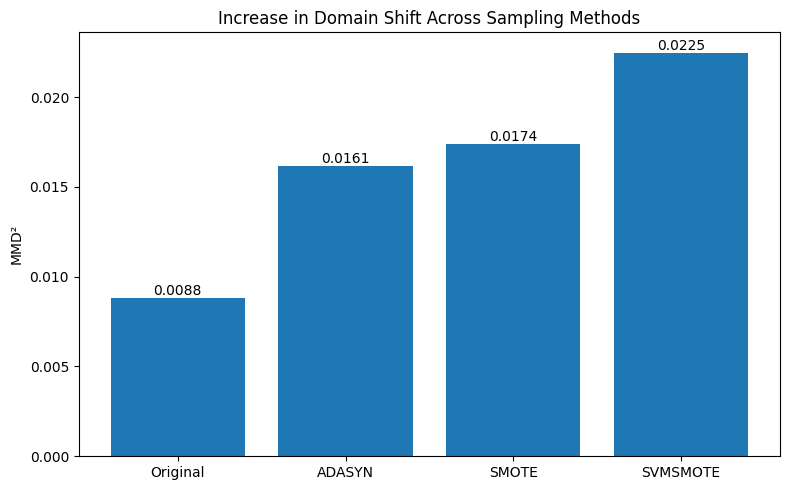

In [16]:
import numpy as np

methods = np.array(["Original", "SMOTE", "ADASYN", "SVMSMOTE"])
values = np.array([mmd_original, mmd_smote, mmd_adasyn, mmd_svm])

# Sort by value
idx = np.argsort(values)
methods = methods[idx]
values = values[idx]

plt.figure(figsize=(8,5))
plt.bar(methods, values)

plt.ylabel("MMD²")
plt.title("Increase in Domain Shift Across Sampling Methods")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()